# Ictal involvement consistency across multiple seizures

> ## ⚠️ Read this before interpreting the ranking
>
> This measures **how strongly a shaft is involved** during a seizure. That is
> related to, but not the same as, where the seizure *starts*:
>
> - The onset zone is characterised by **low-voltage** fast activity — the
>   signal gets *smaller* and faster.
> - The markers here (line-length, fast-band power) are **amplitude-weighted**,
>   so in principle they can rank a strong propagation target above a
>   low-voltage onset.
>
> **How it actually performed** against the reference dataset's clinical report
> (Step 13): the two documented **EEG onset** shafts ranked **2nd and 4th**,
> comfortably above every documented **early-spread** shaft (mean rank 13). So
> it does separate onset from spread here — better than the amplitude weighting
> would lead you to expect.
>
> **But the top-ranked shaft appeared in neither clinical list**, and remains
> unexplained. A #1 result with no clinical counterpart is exactly where you
> should be most sceptical, not least.
>
> Run Step 13 against your own clinical read before trusting the ordering, and
> read Step 12b — the sham control shows a large part of the between-seizure
> agreement is structural rather than ictal.

Ranks SEEG electrode shafts by how consistently they are involved across several
**independent** seizures.

**The question this answers:** if you analyse N separate seizures with identical
windows and no per-seizure tuning, do the same contacts keep coming top?
Agreement across separate events hours or days apart is much harder to fake than
any score computed from a single seizure.

## What this deliberately does *not* use

- **No Epileptogenicity Index.** EI depends on a change-point detector that can
  be impossible to calibrate to zero false alarms, and because EI weights
  channels by `1/(onset - earliest_onset)`, a single false alarm captures the
  entire ranking.
- **No machine learning**, no training data, no tuned thresholds.

Instead: two simple markers that share no machinery with each other —
**line-length** and **fast-band power increase**. A contact scores only if
*both* independent measures rank it highly.

## Honest limitations

- Shaft-level results replicate; **individual contact rankings often do not**.
- This is a quantitative marker of ictal involvement. It is **not** a clinical
  determination of the seizure onset zone, and is not validated against
  surgical outcome.
- It is blind to clinical annotations — they are never loaded.

---
## Adapting this to another dataset

Everything patient-specific lives in **Step 2 (configuration)** and
**Step 3 (the seizure list)**. To run on different data you need:

1. One EDF per seizure, each containing pre-ictal baseline **and** the seizure.
2. The onset time (seconds) within each file — from your review software's
   annotations.
3. Contact channel names that parse as *shaft + optional prime + number*
   (`A7`, `G'12`). Adjust `CONTACT_RE` if your centre differs.
4. `MAINS_FREQ` matching the local power grid.

Analysis windows are expressed as **offsets relative to each seizure's own
onset**, so clips of different lengths with onsets at different positions are
handled without editing anything else.

## Step 1 — Requirements

```
pip install mne numpy scipy matplotlib
```

In [1]:
import os
import re
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy.signal import butter, filtfilt, iirnotch, spectrogram
from scipy.stats import hypergeom

mne.set_log_level("ERROR")
print("mne", mne.__version__, "| numpy", np.__version__)

mne 1.12.1 | numpy 2.5.1


## Step 2 — Configuration

**`MAINS_FREQ` is the setting most likely to be wrong.** It must match the power
grid the data was recorded on — 60 Hz in North America, 50 Hz in Europe/Asia.
Get it wrong and you notch clean signal while leaving the real interference in
place. At 60 Hz the third harmonic (180 Hz) sits inside the HFO ripple band.

In [2]:
EDF_DIR = r"c:/dev/BrainQuake/datasets/Bella"

MAINS_FREQ = 60.0        # 60 = North America, 50 = Europe/Asia

# Windows are offsets RELATIVE TO EACH SEIZURE'S OWN onset (set per clip in
# Step 3), never absolute times -- that is what makes this portable.
BASELINE_OFFSET = (-100.0, -25.0)   # pre-ictal; ends 25s before onset
TARGET_OFFSET   = (-20.0,  +60.0)   # opens 20s before onset, first minute of ictus

TOP_K = 10               # channels each marker nominates per seizure

BANDPASS   = (1.0, 200.0)    # broadband cleanup
FAST_BAND  = (12.4, 97.0)    # beta + gamma, where onset energy appears

# --- Channel naming -------------------------------------------------------
# Non-SEEG channels to exclude. These are Nihon Kohden conventions; other
# systems name their reference/DC/ECG channels differently. Step 4 prints what
# actually got dropped so you can check this against your own montage.
DROP_RE = re.compile(
    r"^(DC\d+|EKG\d+|ECG\d+|EEG\d+|UNUSED\d+|REF\d+|E|BN|AV|SD|Aav|0V|MARK.*|Annotations?)$",
    re.I)

# A contact: shaft letters + optional prime (hemisphere) + contact number.
CONTACT_RE = re.compile(r"^([A-Za-z]+'?)(\d+)$")


def shaft_of(name):
    # 'A7-8' -> 'A';  "G'3-4" -> "G'"
    return CONTACT_RE.match(name.split("-")[0]).group(1)


def windows_for(onset):
    # absolute (baseline, target) windows for a seizure at `onset` seconds
    return ((onset + BASELINE_OFFSET[0], onset + BASELINE_OFFSET[1]),
            (onset + TARGET_OFFSET[0],   onset + TARGET_OFFSET[1]))


print(f"mains {MAINS_FREQ:g} Hz | baseline {BASELINE_OFFSET} | target {TARGET_OFFSET} (s rel. onset)")

mains 60 Hz | baseline (-100.0, -25.0) | target (-20.0, 60.0) (s rel. onset)


## Step 3 — Find the seizures automatically

Rather than a hand-typed table of filenames and onset times, this **reads the
clinical annotations embedded in the EDFs** and finds the seizures itself.

That matters for more than convenience. A hand-entered onset time is a number
copied from a viewer by a human who already knows the answer; reading it from
the file removes that step, and makes the selection criterion explicit and
auditable instead of implicit.

`SEIZURE_RE` is the pattern that identifies a seizure annotation at your centre.
Print the annotations of one file first (next cell) and check what yours look
like before trusting the match.

**This does not remove selection bias.** The clips still exist because a
clinician marked them, and their marks still determine which data is analysed.
It only removes the transcription step.

In [3]:
import glob

# What a seizure annotation looks like in your recordings. The reference data
# uses the clinical shorthand "SZ 1P" ... "SZ 8P" for the numbered clinical
# seizures. Inspect a file's annotations before changing this.
SEIZURE_RE = re.compile(r"^SZ\s*\d+\s*P$", re.I)

# Set to a dict to bypass auto-discovery entirely:
#   CLIPS_OVERRIDE = {"SZ 1P": ("file.edf", 120.0, "note"), ...}
CLIPS_OVERRIDE = None


def discover_seizures(edf_dir, pattern=SEIZURE_RE):
    # -> {label: (filename, onset_seconds, "YYYY-MM-DD HH:MM")}
    found = {}
    for path in sorted(glob.glob(os.path.join(edf_dir, "*.edf"))):
        raw = mne.io.read_raw_edf(path, preload=False, stim_channel=None)
        start = raw.info["meas_date"]
        for onset, _dur, text in zip(raw.annotations.onset,
                                     raw.annotations.duration,
                                     raw.annotations.description):
            label = text.strip()
            if not pattern.match(label):
                continue
            base, targ = windows_for(onset)
            if base[0] < 0 or targ[1] > raw.times[-1]:
                print(f"  skipping {label} in {os.path.basename(path)}: "
                      f"windows {base[0]:.0f}..{targ[1]:.0f}s do not fit a "
                      f"{raw.times[-1]:.0f}s file")
                continue
            when = start.strftime("%Y-%m-%d %H:%M") if start else "?"
            found[label] = (os.path.basename(path), float(onset), when)
    return dict(sorted(found.items()))


CLIPS = CLIPS_OVERRIDE or discover_seizures(EDF_DIR)
if not CLIPS:
    raise ValueError(
        f"No annotations matching {SEIZURE_RE.pattern!r} found in {EDF_DIR}. "
        f"Print one file's annotations and adjust SEIZURE_RE, or set "
        f"CLIPS_OVERRIDE.")

for label, (fn, onset, when) in CLIPS.items():
    base, targ = windows_for(onset)
    print(f"  {label:>7}  {when}  onset {onset:7.1f}s   "
          f"baseline {base[0]:6.0f}-{base[1]:<6.0f} target {targ[0]:6.0f}-{targ[1]:<6.0f}  {fn}")
print()
print(f"{len(CLIPS)} seizures discovered from embedded annotations.")

    SZ 1P  2024-03-19 07:22  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_17_20240319072231.edf
    SZ 2P  2024-03-19 17:34  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_20_20240319173404.edf
    SZ 3P  2024-03-19 22:17  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_21_20240319221721.edf
    SZ 4P  2024-03-20 06:02  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_22_20240320060204.edf
    SZ 5P  2024-03-21 03:36  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_26_20240321033634.edf
    SZ 6P  2024-03-21 07:00  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_27_20240321070053.edf
    SZ 7P  2024-03-21 12:58  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_29_20240321125835.edf
    SZ 8P  2024-03-22 22:10  onset   120.0s   baseline     20-95     target    100-180     DA6465AU_44_20240322221053.edf

8 seizures discovered f

### What else is annotated?

Worth reading before you trust the auto-discovery — it shows the full clinical
timeline around one seizure, and lets you confirm `SEIZURE_RE` is matching the
right thing and not, say, a sub-clinical or "?SZ" entry.

In [4]:
_first = list(CLIPS)[0]
_raw = mne.io.read_raw_edf(os.path.join(EDF_DIR, CLIPS[_first][0]),
                           preload=False, stim_channel=None)
_onset = CLIPS[_first][1]
print(f"annotations in {CLIPS[_first][0]} near {_first} (t relative to seizure):")
for o, t in zip(_raw.annotations.onset, _raw.annotations.description):
    if _onset - 60 <= o <= _onset + 60:
        print(f"   {o - _onset:+7.1f}s   {t}")

annotations in DA6465AU_17_20240319072231.edf near SZ 1P (t relative to seizure):
     -40.0s   IA SPKing
     -19.0s   in bed with dad
     -15.0s   A LVFA -> broad
      -3.0s   EEG onset
      +0.0s   SZ 1P
      +1.0s   FP_Onset
      +2.0s   CLUSTER
      +2.0s   L leg proximal tonic
      +2.0s   clinical onset
      +2.0s   distal L leg dystoni
      +3.0s   L hip flexion
      +4.0s   L hip & arm tonic fl
      +4.0s   moaning/throat sound
      +9.0s   MARK ON
     +11.0s   clonic L leg & arm
     +11.0s   face not seen
     +27.0s   eyes up & left
     +32.0s   R arm flexed
     +34.0s   lower jaw contractio
     +38.0s   MARK OFF
     +44.0s   end
     +59.0s   SZ
     +59.0s   axial left, R arm co
     +59.0s   spasm


## Step 4 — Bipolar montage

SEEG is recorded against one shared reference, so every channel carries a copy
of whatever that reference picks up. Subtracting **adjacent contacts on the same
shaft** cancels the shared component and leaves a signal local to the few
millimetres between the two contacts.

Skip this and a single strong generator appears on all ~200 channels, making
localisation meaningless.

Only *physically adjacent* contacts are paired (A1-A2, A2-A3, …); where a
contact number is missing, no pair is formed across the gap.

In [5]:
# EDF -> (bipolar data in uV, channel names, sampling rate)
# `upto` limits how much is read; None loads the whole file.
def load_bipolar(path, upto=None, verbose=False):
    raw = mne.io.read_raw_edf(path, preload=False, stim_channel=None)
    fs = raw.info["sfreq"]
    if upto is not None:
        raw.crop(0.0, min(upto, raw.times[-1]))
    raw.load_data()
    data = raw.get_data() * 1e6                      # volts -> microvolts

    shafts, dropped, unparsed = defaultdict(list), [], []
    for i, name in enumerate(raw.ch_names):
        if DROP_RE.match(name):
            dropped.append(name)
            continue
        m = CONTACT_RE.match(name)
        if m:
            shafts[m.group(1)].append((int(m.group(2)), i))
        else:
            unparsed.append(name)

    if verbose:
        print(f"  {len(raw.ch_names)} channels -> dropped {len(dropped)} non-SEEG: {dropped}")
        if unparsed:
            print(f"  WARNING unparsed (check CONTACT_RE): {unparsed}")

    bip, names = [], []
    for shaft, contacts in sorted(shafts.items()):
        contacts.sort()
        for (n_a, i_a), (n_b, i_b) in zip(contacts[:-1], contacts[1:]):
            if n_b == n_a + 1:                       # adjacent only
                bip.append(data[i_a] - data[i_b])
                names.append(f"{shaft}{n_a}-{n_b}")
    if not bip:
        raise ValueError(f"No bipolar pairs built from {os.path.basename(path)} -- "
                         f"check DROP_RE / CONTACT_RE against these channel names: "
                         f"{raw.ch_names[:15]}")
    return np.array(bip), names, fs


demo_label = list(CLIPS)[0]
demo_fn, demo_onset, _ = CLIPS[demo_label]
DEMO_BASE, DEMO_TARG = windows_for(demo_onset)
print(f"loading {demo_label}:")
X, CH_NAMES, FS = load_bipolar(os.path.join(EDF_DIR, demo_fn),
                               upto=DEMO_TARG[1] + 20, verbose=True)
print(f"\n{X.shape[0]} bipolar channels @ {FS:g} Hz")
print("first 8:", CH_NAMES[:8])

loading SZ 1P:


  204 channels -> dropped 20 non-SEEG: ['REF1', 'REF2', 'E', 'DC01', 'DC02', 'DC03', 'DC04', 'DC05', 'DC06', 'DC07', 'DC08', 'DC09', 'DC10', 'UNUSED248', 'UNUSED249', 'UNUSED250', 'UNUSED251', 'EKG1', 'EKG2', 'MARK']



164 bipolar channels @ 1000 Hz
first 8: ['A1-2', 'A2-3', 'A3-4', 'A4-5', 'A5-6', 'A6-7', 'A7-8', 'A8-9']


### Montage consistency across clips

The size normalisation in Step 10 divides by the number of bipolar pairs per
shaft, so that count must be identical across every seizure. If two clips were
recorded with different montages, comparing their vote totals would be
meaningless — so this checks rather than assumes.

In [6]:
REF_NAMES = None
for label, (fn, onset, _) in CLIPS.items():
    raw = mne.io.read_raw_edf(os.path.join(EDF_DIR, fn), preload=False, stim_channel=None)
    shafts = defaultdict(list)
    for i, name in enumerate(raw.ch_names):
        if DROP_RE.match(name):
            continue
        m = CONTACT_RE.match(name)
        if m:
            shafts[m.group(1)].append(int(m.group(2)))
    names = [f"{s}{a}-{a+1}" for s, cs in sorted(shafts.items())
             for a, b in zip(sorted(cs)[:-1], sorted(cs)[1:]) if b == a + 1]
    if REF_NAMES is None:
        REF_NAMES = names
    elif names != REF_NAMES:
        raise ValueError(f"{label} has a different montage than {list(CLIPS)[0]} -- "
                         f"vote normalisation would be invalid.")

PAIRS_PER_SHAFT = defaultdict(int)
for n in REF_NAMES:
    PAIRS_PER_SHAFT[shaft_of(n)] += 1

print(f"all {len(CLIPS)} clips share an identical montage: "
      f"{len(REF_NAMES)} bipolar channels, {len(PAIRS_PER_SHAFT)} shafts\n")
for s, k in sorted(PAIRS_PER_SHAFT.items(), key=lambda kv: -kv[1]):
    print(f"  {s:>4}  {k:2d} pairs")

all 8 clips share an identical montage: 164 bipolar channels, 20 shafts

    K'  11 pairs
    L'  11 pairs
     X  11 pairs
    X'  11 pairs
     A   9 pairs
     F   9 pairs
     G   9 pairs
    G'   9 pairs
     K   9 pairs
     L   9 pairs
    M'   9 pairs
     P   9 pairs
     B   7 pairs
     M   7 pairs
     N   7 pairs
     S   7 pairs
     D   5 pairs
     I   5 pairs
     Q   5 pairs
     T   5 pairs


## Step 5 — Preprocessing

1. **Notch the mains harmonics** — at 60 Hz that means 60, 120, 180, 240 …
2. **Bandpass** to remove drift and out-of-band noise.

Both are zero-phase (`filtfilt`), so nothing is shifted in time — essential when
the whole question is which channel leads.

In [7]:
def preprocess(x, fs, mains=MAINS_FREQ, band=BANDPASS):
    for f0 in np.arange(mains, fs / 2 * 0.99, mains):
        b, a = iirnotch(f0 / (fs / 2), 30)
        x = filtfilt(b, a, x, axis=-1)
    hi = min(band[1], fs / 2 * 0.99)          # never request >= Nyquist
    b, a = butter(4, [band[0] / (fs / 2), hi / (fs / 2)], btype="bandpass")
    return filtfilt(b, a, x, axis=-1)


print("notching:", np.arange(MAINS_FREQ, FS / 2 * 0.99, MAINS_FREQ), "Hz")
Xf = preprocess(X, FS)
print("filtered:", Xf.shape)

notching: [ 60. 120. 180. 240. 300. 360. 420. 480.] Hz


filtered: (164, 200001)


## Step 6 — The two markers

Both compare **target** against **baseline**, per channel.

**Line-length** — mean absolute sample-to-sample change. A robust proxy for how
much a signal is moving, sensitive to both amplitude and frequency.

**Fast-band power** — power in 12.4–97 Hz (beta + gamma). Seizure onset
characteristically shifts energy into these fast bands.

Deliberately different in construction: one a time-domain difference, the other
a frequency-domain integral. A channel topping both is unlikely to be doing so
for a shared artefactual reason.

In [8]:
def line_length_ratio(x, fs, base, targ):
    d = np.abs(np.diff(x, axis=-1))
    t = np.arange(d.shape[1]) / fs
    tgt = d[:, (t >= targ[0]) & (t < targ[1])].mean(1)
    bas = d[:, (t >= base[0]) & (t < base[1])].mean(1)
    return tgt / np.maximum(bas, 1e-12)


def fast_power_ratio(x, fs, base, targ, band=FAST_BAND):
    f, t, S = spectrogram(x, fs=fs, nperseg=int(fs), noverlap=int(fs * 0.5),
                          axis=-1, mode="psd")
    sel = (f >= band[0]) & (f < band[1])
    p = S[..., sel, :].sum(axis=-2)
    tgt = p[:, (t >= targ[0]) & (t < targ[1])].mean(1)
    bas = p[:, (t >= base[0]) & (t < base[1])].mean(1)
    return tgt / np.maximum(bas, 1e-20)


ll = line_length_ratio(Xf, FS, DEMO_BASE, DEMO_TARG)
fp = fast_power_ratio(Xf, FS, DEMO_BASE, DEMO_TARG)
print("line-length ratio : min %.2f  median %.2f  max %.1f" % (ll.min(), np.median(ll), ll.max()))
print("fast-power ratio  : min %.2f  median %.2f  max %.0f" % (fp.min(), np.median(fp), fp.max()))

line-length ratio : min 0.92  median 2.96  max 8.4
fast-power ratio  : min 0.79  median 28.82  max 2357


## Step 7 — One seizure

Each marker nominates its top `TOP_K`. The **intersection** is what matters:
channels both agree on.

In [9]:
def top_sets(ll, fp, k=TOP_K):
    a = set(np.argsort(-ll)[:k])
    b = set(np.argsort(-fp)[:k])
    return a, b, sorted(a & b, key=lambda i: -ll[i])


a, b, both = top_sets(ll, fp)
print("line-length top :", [CH_NAMES[i] for i in sorted(a, key=lambda i: -ll[i])])
print("fast-power  top :", [CH_NAMES[i] for i in sorted(b, key=lambda i: -fp[i])])
print()
print("BOTH agree on   :", [CH_NAMES[i] for i in both])

n_ch = len(CH_NAMES)
print(f"\nexpected overlap by chance: {TOP_K * TOP_K / n_ch:.2f}")
print(f"P(overlap >= {len(both)}) = {hypergeom.sf(len(both) - 1, n_ch, TOP_K, TOP_K):.2g}")

line-length top : ['B6-7', 'T3-4', 'A7-8', 'I4-5', 'A8-9', 'B7-8', 'T2-3', 'F8-9', 'Q3-4', 'Q2-3']
fast-power  top : ['T3-4', "M'8-9", "X'10-11", 'T2-3', 'A8-9', 'T4-5', 'L8-9', 'A7-8', 'T5-6', 'D4-5']

BOTH agree on   : ['T3-4', 'A7-8', 'A8-9', 'T2-3']

expected overlap by chance: 0.61
P(overlap >= 4) = 0.0013


## Step 8 — All seizures

Identical window *offsets*, identical parameters, no per-seizure tuning. Each
seizure contributes votes from the **union** of its two top-K lists.

In [10]:
votes_contact = defaultdict(int)
votes_shaft = defaultdict(int)
per_seizure = {}

for label, (fn, onset, when) in CLIPS.items():
    base, targ = windows_for(onset)
    Xi, names_i, fs_i = load_bipolar(os.path.join(EDF_DIR, fn), upto=targ[1] + 20)
    Xi = preprocess(Xi, fs_i)
    ll_i = line_length_ratio(Xi, fs_i, base, targ)
    fp_i = fast_power_ratio(Xi, fs_i, base, targ)
    a_i, b_i, both_i = top_sets(ll_i, fp_i)
    per_seizure[label] = (a_i, b_i, names_i)

    for i in a_i | b_i:
        votes_contact[names_i[i]] += 1
        votes_shaft[shaft_of(names_i[i])] += 1

    print(f"{label}  {when}   both markers agree on: {[names_i[i] for i in both_i]}")

print(f"\ndone: {len(CLIPS)} seizures, max {2 * TOP_K} votes each")

SZ 1P  2024-03-19 07:22   both markers agree on: ['T3-4', 'A7-8', 'A8-9', 'T2-3']


SZ 2P  2024-03-19 17:34   both markers agree on: ['I5-6', 'T3-4', 'P9-10', 'T2-3', "K'11-12"]


SZ 3P  2024-03-19 22:17   both markers agree on: ['Q4-5', 'Q5-6', 'A7-8', 'T3-4', 'Q2-3', 'T1-2']


SZ 4P  2024-03-20 06:02   both markers agree on: ['A9-10', 'F3-4', 'I5-6', 'F2-3', 'A1-2', 'T3-4', 'B1-2', 'A2-3']


SZ 5P  2024-03-21 03:36   both markers agree on: ['I5-6', 'A1-2', 'A2-3', 'X1-2', 'B1-2', "X'11-12", 'B2-3', 'A4-5', 'I1-2']


SZ 6P  2024-03-21 07:00   both markers agree on: ['I5-6', 'A1-2', "M'5-6", 'A2-3', "M'6-7"]


SZ 7P  2024-03-21 12:58   both markers agree on: ['I5-6', 'A1-2', 'A2-3', 'B1-2', 'X1-2', 'B2-3', 'A4-5', "X'11-12"]


SZ 8P  2024-03-22 22:10   both markers agree on: ['Q4-5', "M'6-7", "M'5-6", 'A8-9', "M'4-5"]

done: 8 seizures, max 20 votes each


## Step 9 — Raw vote totals (the misleading version)

Read naively, one shaft looks like the clear winner.

In [11]:
print(f"{'shaft':>6} {'votes':>6}")
for s, v in sorted(votes_shaft.items(), key=lambda kv: -kv[1])[:10]:
    print(f"{s:>6} {v:6d}  {'#' * v}")

 shaft  votes
     A     22  ######################
     T     16  ################
     B     13  #############
     I      9  #########
     Q      9  #########
    M'      7  #######
     X      6  ######
     L      4  ####
     D      4  ####
     F      4  ####


## Step 10 — Normalise for shaft size

**This correction matters and it can change the answer.**

A shaft with 9 bipolar pairs has nearly twice as many chances to land in a top-K
list as one with 5. Comparing raw totals rewards long electrodes for being long.

Dividing votes by pairs asks the fair question: *per available channel, how often
did this shaft lead?*

In [12]:
ranking = sorted(
    ((s, v, PAIRS_PER_SHAFT[s], v / PAIRS_PER_SHAFT[s]) for s, v in votes_shaft.items()),
    key=lambda r: -r[3],
)

# Mark the single largest discontinuity, rather than any gap over a hardcoded
# size -- that is what "where does this list stop mattering" means, and it
# adapts to another patient's numbers.
gaps = [ranking[i][3] - ranking[i + 1][3] for i in range(len(ranking) - 1)]
break_after = int(np.argmax(gaps)) if gaps else -1

print(f"{'shaft':>6} {'pairs':>6} {'votes':>6} {'votes/pair':>11}")
for i, (s, v, k, norm) in enumerate(ranking):
    print(f"{s:>6} {k:6d} {v:6d} {norm:11.2f}  {'#' * int(norm * 4)}")
    if i == break_after:
        print("  " + "-" * 19 + f" largest break (gap {gaps[i]:.2f})")

 shaft  pairs  votes  votes/pair
     T      5     16        3.20  ############
     A      9     22        2.44  #########
     B      7     13        1.86  #######
     I      5      9        1.80  #######
     Q      5      9        1.80  #######
  ------------------- largest break (gap 1.00)
     D      5      4        0.80  ###
    M'      9      7        0.78  ###
     X     11      6        0.55  ##
     L      9      4        0.44  #
     F      9      4        0.44  #
    K'     11      4        0.36  #
    X'     11      3        0.27  #
     P      9      2        0.22  
    G'      9      2        0.22  
    L'     11      2        0.18  
     S      7      1        0.14  
     N      7      1        0.14  
     G      9      1        0.11  


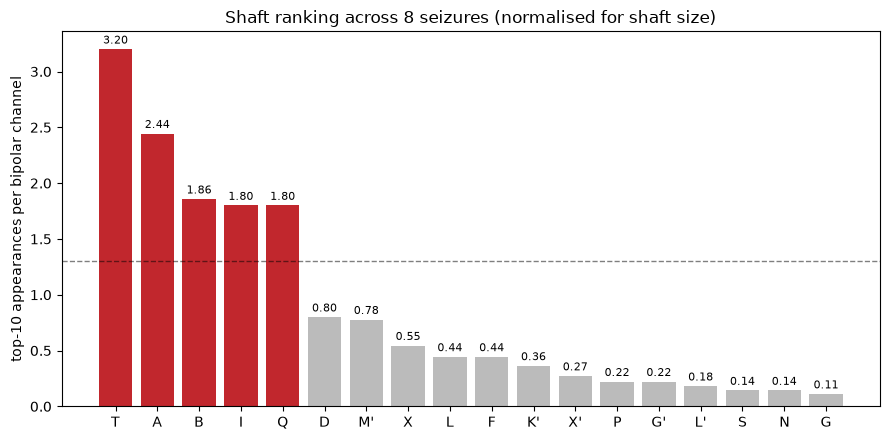

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = [r[0] for r in ranking]
values = [r[3] for r in ranking]
cutoff = values[break_after] if break_after >= 0 else 0
colors = ["#c1272d" if v >= cutoff else "#bbbbbb" for v in values]
ax.bar(labels, values, color=colors)
ax.set_ylabel(f"top-{TOP_K} appearances per bipolar channel")
ax.set_title(f"Shaft ranking across {len(CLIPS)} seizures (normalised for shaft size)")
if break_after >= 0 and break_after + 1 < len(values):
    ax.axhline((values[break_after] + values[break_after + 1]) / 2,
               ls="--", lw=1, color="k", alpha=.5)
for i, v in enumerate(values):
    ax.text(i, v + .05, f"{v:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## Step 11 — Is the agreement real?

The ranking only means something if the seizures actually agree with each other.
A permutation test answers this directly: shuffle which channels each seizure
picks, and see how often random draws reproduce the observed agreement.

In [14]:
rng = np.random.default_rng(0)
labels_list = list(CLIPS)
ll_sets = [per_seizure[l][0] for l in labels_list]
n_ch = len(per_seizure[labels_list[0]][2])
N_PERM = 20000


def mean_pairwise_overlap(sets):
    return np.mean([len(sets[i] & sets[j])
                    for i in range(len(sets)) for j in range(i + 1, len(sets))])


observed = mean_pairwise_overlap(ll_sets)
null = np.array([
    mean_pairwise_overlap([set(rng.choice(n_ch, TOP_K, replace=False)) for _ in labels_list])
    for _ in range(N_PERM)
])
p = (null >= observed).mean()

print(f"observed mean pairwise overlap : {observed:.2f}")
print(f"null (random) mean             : {null.mean():.2f}")
print(f"P(random >= observed)          : {p:.5f}"
      f"{f'  -> < 1/{N_PERM}' if p == 0 else ''}")

observed mean pairwise overlap : 2.39
null (random) mean             : 0.61
P(random >= observed)          : 0.00000  -> < 1/20000


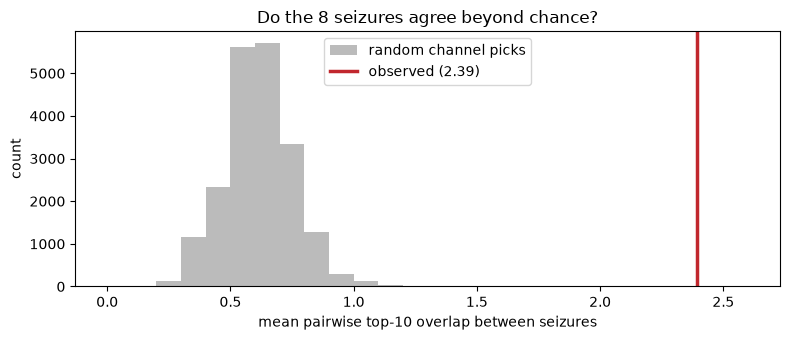

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(null, bins=np.arange(0, max(null.max(), observed) + .3, .1),
        color="#bbbbbb", label="random channel picks")
ax.axvline(observed, color="#c1272d", lw=2.5, label=f"observed ({observed:.2f})")
ax.set_xlabel(f"mean pairwise top-{TOP_K} overlap between seizures")
ax.set_ylabel("count")
ax.legend()
ax.set_title(f"Do the {len(CLIPS)} seizures agree beyond chance?")
plt.tight_layout()
plt.show()

## Step 12 — Most consistent individual contacts

Included for completeness, but treat with care: **shaft-level results replicate,
contact-level ones often do not.** Different seizures may highlight different
contacts along the same shaft.

In [16]:
print(f"{'contact':>10} {'seizures':>9}   (max {2 * len(CLIPS)})")
for name, v in sorted(votes_contact.items(), key=lambda kv: -kv[1])[:15]:
    print(f"{name:>10} {v:9d}   {'#' * v}")

   contact  seizures   (max 16)
      T2-3         5   #####
      T3-4         5   #####
      I5-6         5   #####
      B6-7         4   ####
      L8-9         4   ####
      Q4-5         4   ####
      A1-2         4   ####
      A2-3         4   ####
      B1-2         4   ####
      X1-2         4   ####
      A8-9         3   ###
      T4-5         3   ###
      I4-5         3   ###
     A9-10         3   ###
      A3-4         3   ###


## Step 12b — Negative control (sham): is this seizure-specific at all?

The permutation test in Step 11 compares against *random channel picks*. That is
the wrong null. Electrodes differ systematically in impedance, tissue type and
baseline amplitude, so some agreement between seizures is expected **even with
no seizure present**.

The right control re-runs everything with **both windows placed entirely in the
pre-ictal period**, where there is definitively no seizure. Whatever survives
that is structural, not ictal.

In [17]:
# both windows before onset -- no seizure in either
SHAM_BASELINE_OFFSET = (-100.0, -63.0)
SHAM_TARGET_OFFSET   = (-62.0,  -25.0)


def run_pass(base_off, targ_off):
    votes, sets = defaultdict(int), []
    for label, (fn, onset, _) in CLIPS.items():
        base = (onset + base_off[0], onset + base_off[1])
        targ = (onset + targ_off[0], onset + targ_off[1])
        Xi, names_i, fs_i = load_bipolar(os.path.join(EDF_DIR, fn),
                                         upto=max(targ[1], base[1]) + 20)
        Xi = preprocess(Xi, fs_i)
        ll_i = line_length_ratio(Xi, fs_i, base, targ)
        fp_i = fast_power_ratio(Xi, fs_i, base, targ)
        a_i, b_i, _ = top_sets(ll_i, fp_i)
        sets.append(a_i)
        for i in a_i | b_i:
            votes[shaft_of(names_i[i])] += 1
    norm = {s: votes[s] / PAIRS_PER_SHAFT[s] for s in PAIRS_PER_SHAFT}
    ov = np.array([len(sets[i] & sets[j])
                   for i in range(len(sets)) for j in range(i + 1, len(sets))])
    return norm, ov


real_norm, real_ov = run_pass(BASELINE_OFFSET, TARGET_OFFSET)
sham_norm, sham_ov = run_pass(SHAM_BASELINE_OFFSET, SHAM_TARGET_OFFSET)

from scipy.stats import mannwhitneyu
_, p_sham = mannwhitneyu(real_ov, sham_ov, alternative="greater")

print(f"agreement between seizures:  real {real_ov.mean():.2f}   "
      f"SHAM {sham_ov.mean():.2f}   pure chance {TOP_K*TOP_K/len(REF_NAMES):.2f}")
print(f"real > sham?  Mann-Whitney p = {p_sham:.4f}")
print()
print("Structure-corrected ranking (real - sham):")
print(f"{'shaft':>6} {'real':>6} {'sham':>6} {'diff':>7}")
for s in sorted(real_norm, key=lambda s: -(real_norm[s] - sham_norm[s]))[:8]:
    d = real_norm[s] - sham_norm[s]
    print(f"{s:>6} {real_norm[s]:6.2f} {sham_norm[s]:6.2f} {d:+7.2f}"
          f"  {'#' * int(max(d, 0) * 6)}")

agreement between seizures:  real 2.39   SHAM 1.32   pure chance 0.61
real > sham?  Mann-Whitney p = 0.0310

Structure-corrected ranking (real - sham):
 shaft   real   sham    diff
     T   3.20   1.20   +2.00  ############
     Q   1.80   0.20   +1.60  #########
     B   1.86   0.57   +1.29  #######
     A   2.44   1.67   +0.78  ####
    M'   0.78   0.33   +0.44  ##
     F   0.44   0.44   +0.00  
     G   0.11   0.11   +0.00  
    K'   0.36   0.36   +0.00  


## Step 13 — Validation against a documented clinical read

**This is the cell that tells you whether to believe any of the above.**

If you have the epileptologists' own summary of ictal activity, encode it here.
The method should recover the **EEG onset** shafts. If instead it recovers the
**early spread** shafts, it is measuring propagation — which is exactly what
amplitude-weighted markers do.

The values below are from the reference dataset's clinical report. Replace them
with your own, or set both to `None` to skip.

In [18]:
# From the clinical "Summary of ictal activity". Replace for your own patient.
CLINICAL_ONSET  = {"A", "I"}                            # A1-3 amygdala, I1-3 temporal pole
CLINICAL_SPREAD = {"N", "P", "G", "L", "K", "Q", "S"}   # documented early spread

if CLINICAL_ONSET:
    order = [s for s, _, _, _ in ranking]
    print(f"{'rank':>4} {'shaft':>6} {'votes/pair':>11}   clinical label")
    for i, (s, v, k, norm) in enumerate(ranking[:10], 1):
        tag = ("<<< EEG ONSET" if s in CLINICAL_ONSET
               else "early spread" if s in CLINICAL_SPREAD else "")
        print(f"{i:4d} {s:>6} {norm:11.2f}   {tag}")

    onset_ranks = [order.index(s) + 1 for s in CLINICAL_ONSET if s in order]
    spread_ranks = [order.index(s) + 1 for s in CLINICAL_SPREAD if s in order]
    print()
    print(f"clinical ONSET shafts rank : {sorted(onset_ranks)}  (mean {np.mean(onset_ranks):.1f})")
    print(f"clinical SPREAD shafts rank: {sorted(spread_ranks)}  (mean {np.mean(spread_ranks):.1f})")
    print()
    if np.mean(onset_ranks) > np.mean(spread_ranks):
        print("RESULT: spread shafts rank HIGHER than onset shafts.")
        print("        This method is tracking propagation, not onset. Do not")
        print("        interpret the top of the ranking as a seizure onset zone.")
    else:
        print("RESULT: onset shafts rank above spread shafts on this dataset.")

rank  shaft  votes/pair   clinical label
   1      T        3.20   
   2      A        2.44   <<< EEG ONSET
   3      B        1.86   
   4      I        1.80   <<< EEG ONSET
   5      Q        1.80   early spread
   6      D        0.80   
   7     M'        0.78   
   8      X        0.55   
   9      L        0.44   early spread
  10      F        0.44   

clinical ONSET shafts rank : [2, 4]  (mean 3.0)
clinical SPREAD shafts rank: [5, 9, 13, 16, 17, 18]  (mean 13.0)

RESULT: onset shafts rank above spread shafts on this dataset.


## Summary

Seizures analysed with identical window offsets and no tuning keep selecting the
same shafts, at a rate the permutation test can evaluate against chance.

**Read Steps 12b and 13 before drawing any conclusion.**

On the reference dataset the ranking placed the clinically documented EEG-onset
shafts 2nd and 4th, above all documented early-spread shafts — but the shaft it
ranked *1st* appears nowhere in the clinical report. Treat an unexplained top
result as a reason for scepticism, not a discovery.

The sham control also shows the between-seizure agreement is only modestly
better than with no seizure present (p ~ 0.03), so a large share of the apparent
reproducibility is structural — consistent electrode impedance and tissue
properties, not ictal activity.

A further trap found on this dataset: metrics normalised by baseline variability
systematically **penalise the true onset zone**, because the onset zone is also
where the interictal spiking is, which inflates its baseline variance. Several
plausible timing metrics put the wrong hemisphere first for this reason.

**Before drawing conclusions from shaft names, map them to anatomy.** The letters
are assigned by the implanting team and mean nothing on their own — they become
interpretable only via the implantation plan or a post-implant CT/MRI
coregistration. Two shafts with adjacent letters can be in different lobes.

**What this is not:** a clinical determination of the seizure onset zone. It is a
reproducible quantitative marker of which shafts lead at seizure onset, generated
blind to the clinical annotations. Any use of it belongs in a conversation with
the treating epilepsy team, alongside the annotations, imaging and semiology —
not instead of them.